# 文件: chart_161_1.py

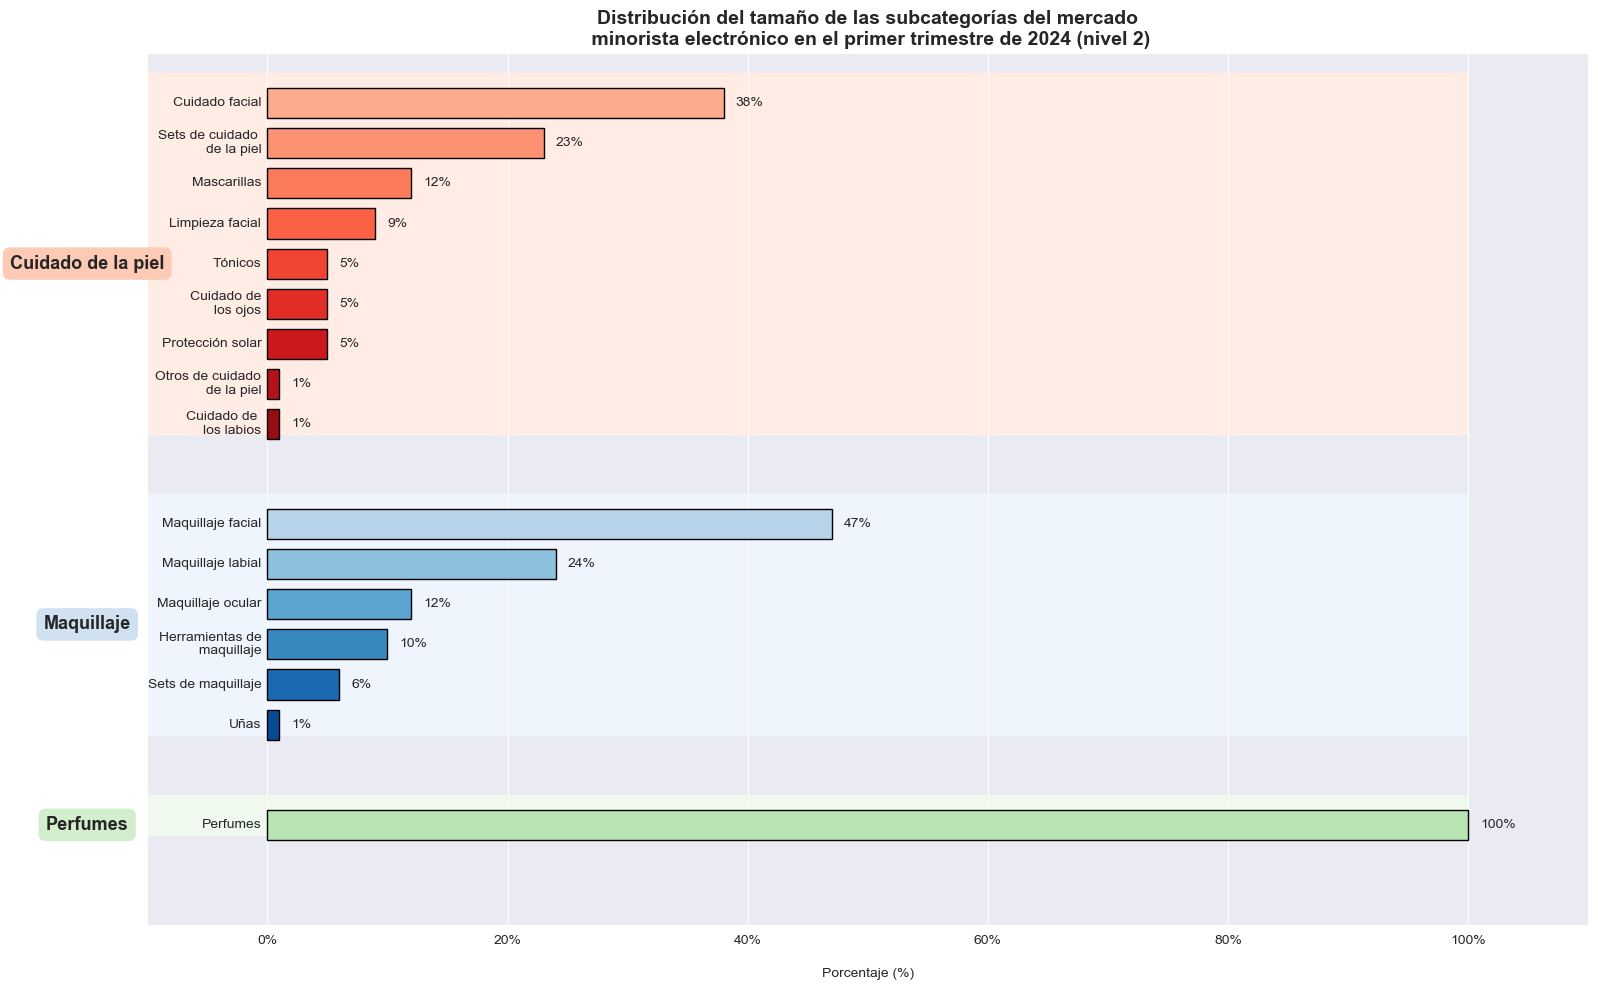

In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Datos
categorias = {
    'Cuidado de la piel': {
        'etiquetas': ['Cuidado facial', 'Sets de cuidado \nde la piel', 'Mascarillas', 'Limpieza facial', 'Tónicos', 'Cuidado de\n los ojos', 'Protección solar', 'Otros de cuidado\n de la piel', 'Cuidado de \nlos labios'],
        'valores': [38, 23, 12, 9, 5, 5, 5, 1, 1],
        'color': 'Reds'
    },
    'Maquillaje': {
        'etiquetas': ['Maquillaje facial', 'Maquillaje labial', 'Maquillaje ocular', 'Herramientas de\n maquillaje', 'Sets de maquillaje', 'Uñas'],
        'valores': [47, 24, 12, 10, 6, 1],
        'color': 'Blues'
    },
    'Perfumes': {
        'etiquetas': ['Perfumes'],
        'valores': [100],
        'color': 'Greens'
    }
}

# Inicializar la gráfica
fig, ax = plt.subplots(figsize=(16,10))
y_base = 0
altura_barra = 0.6
espacio_grupo = 1.2
relleno_etiqueta = 0.5

# Bucle principal de trazado
for indice_grupo, (grupo, contenido) in enumerate(categorias.items()):
    etiquetas = contenido['etiquetas']
    valores = contenido['valores']
    mapa_color = plt.get_cmap(contenido['color'])
    num_elementos = len(valores)

    # Escala de colores
    colores = [mapa_color(0.3 + 0.6 * i / max(len(valores)-1, 1)) for i in range(len(valores))]

    # Bloque de fondo
    ax.add_patch(
        patches.Rectangle(
            (-10, y_base - altura_barra/2 - 0.3),
            110, num_elementos * (altura_barra + 0.2),
            color=mapa_color(0.05), zorder=0
        )
    )

    # Etiqueta del nombre del grupo a la izquierda
    ax.text(-15, y_base + (num_elementos - 1) * (altura_barra + 0.2)/2,
            f'{grupo}', va='center', ha='center',
            fontsize=13, weight='bold', bbox=dict(facecolor=mapa_color(0.2), boxstyle='round,pad=0.4', edgecolor='none'))

    for i, (etiqueta, valor) in enumerate(zip(etiquetas, valores)):
        y = y_base + i * (altura_barra + 0.2)
        ax.barh(y, valor, height=altura_barra, color=colores[i], edgecolor='black')
        ax.text(valor + 1, y, f'{valor}%', va='center', ha='left', fontsize=10)
        ax.text(-0.5, y, etiqueta, va='center', ha='right', fontsize=10)

    y_base += num_elementos * (altura_barra + 0.2) + espacio_grupo

# Configuración de formato
ax.set_xlim(-10, 110)
ax.set_ylim(-1, y_base)
ax.set_xticks(range(0, 101, 20))
ax.set_xticklabels([f'{x}%' for x in range(0, 101, 20)])
ax.set_yticks([])
ax.set_xlabel('Porcentaje (%)', labelpad=15)
ax.set_title('Distribución del tamaño de las subcategorías del mercado\n'
             ' minorista electrónico en el primer trimestre de 2024 (nivel 2)', fontsize=14, weight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# 文件: chart_161_2.py

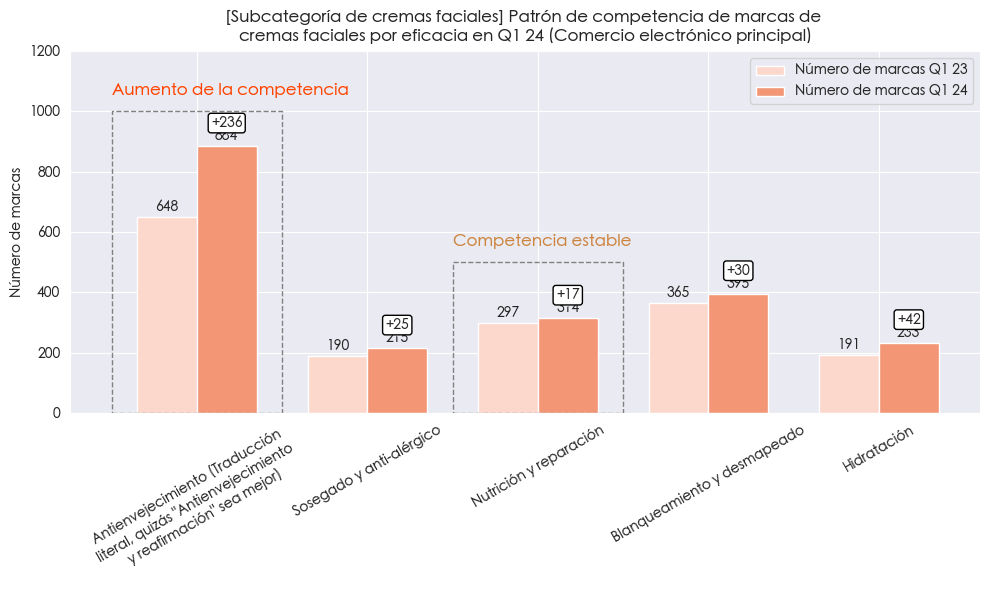

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as patches
from matplotlib import font_manager as fm


# Datos
categorias = ['Antienvejecimiento (Traducción \n'
              'literal, quizás "Antienvejecimiento \n'
              'y reafirmación" sea mejor)',
              'Sosegado y anti-alérgico',
              'Nutrición y reparación',
              'Blanqueamiento y desmapeado', 'Hidratación']
q1_2023 = [648, 190, 297, 365, 191]
q1_2024 = [884, 215, 314, 395, 233]
crecimiento = [q1_2024[i] - q1_2023[i] for i in range(len(q1_2023))]

x = np.arange(len(categorias))
ancho = 0.35

# Configuración de colores
color_2023 = '#fcd7cc'
color_2024 = '#f29676'

fig, ax = plt.subplots(figsize=(10, 6))
barras1 = ax.bar(x - ancho/2, q1_2023, ancho, label='Número de marcas Q1 23', color=color_2023)
barras2 = ax.bar(x + ancho/2, q1_2024, ancho, label='Número de marcas Q1 24', color=color_2024)

# Etiquetas de valores
for i in range(len(x)):
    ax.text(x[i] - ancho/2, q1_2023[i] + 10, str(q1_2023[i]), ha='center', va='bottom', fontsize=10)
    ax.text(x[i] + ancho/2, q1_2024[i] + 10, str(q1_2024[i]), ha='center', va='bottom', fontsize=10)
    ax.annotate(f'+{crecimiento[i]}',
                xy=(x[i] + ancho/2, q1_2024[i] + 40),
                xytext=(x[i] + ancho/2, q1_2024[i] + 60),
                ha='center',
                arrowprops=dict(facecolor='black', arrowstyle='->'),
                fontsize=10,
                bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='black', lw=1))

# Área de borde de grupo
ax.add_patch(patches.Rectangle((-0.5, 0), 1.0, 1000, fill=False, edgecolor='gray', linestyle='--', linewidth=1))
ax.text(-0.5, 1050, 'Aumento de la competencia', color='orangered', fontsize=12)

ax.add_patch(patches.Rectangle((1.5, 0), 1.0, 500, fill=False, edgecolor='gray', linestyle='--', linewidth=1))
ax.text(1.5, 550, 'Competencia estable', color='peru', fontsize=12)

# Resto de configuraciones
ax.set_xticks(x)
ax.set_xticklabels(categorias, rotation=30)
ax.set_ylabel('Número de marcas')
ax.set_ylim(0, 1200)

ax.set_title('[Subcategoría de cremas faciales] Patrón de competencia de marcas de \n'
             'cremas faciales por eficacia en Q1 24 (Comercio electrónico principal)')
ax.legend()

plt.tight_layout()
plt.show()

# 文件: chart_161_3.py

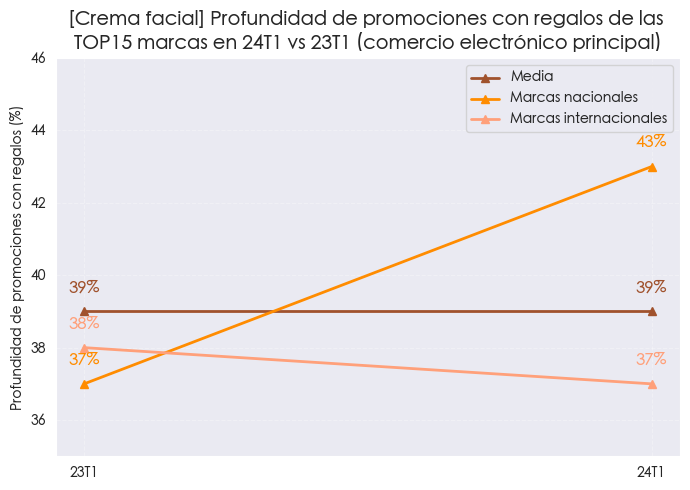

In [15]:
import matplotlib.pyplot as plt

# 数据
trimestres = ['23T1', '24T1']
categorias = ['Media', 'Marcas nacionales', 'Marcas internacionales']
datos = {
    'Media': [39, 39],
    'Marcas nacionales': [37, 43],
    'Marcas internacionales': [38, 37]
}
colores = ['#A0522D', '#FF8C00', '#FFA07A']  # Usar una combinación de colores similar a la imagen original

# Dibujar la gráfica
fig, ax = plt.subplots(figsize=(7, 5))
for idx, cat in enumerate(categorias):
    ax.plot(trimestres, datos[cat], marker='^', label=cat, color=colores[idx], linewidth=2)

# Agregar etiquetas de texto
for idx, cat in enumerate(categorias):
    for i, trimestre in enumerate(trimestres):
        ax.text(trimestre, datos[cat][i] + 0.5, f"{datos[cat][i]}%", color=colores[idx], ha='center', fontsize=12)

# Configuración de estilo
ax.set_ylim(35, 46)
ax.set_title("[Crema facial] Profundidad de promociones con regalos de las \n"
             "TOP15 marcas en 24T1 vs 23T1 (comercio electrónico principal)", fontsize=14, weight='bold')
ax.legend(loc='best')
ax.set_ylabel("Profundidad de promociones con regalos (%)")
ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()